# Mini Project 3: Biomass moisture prediction from FT-NIR spectra

### Author: Donald Yeboah

This project evaluates ML approaches for predicting biomass moisture content using FT-NIR spectral measurements. Multiple chemometric preprocessing techniques were evaluated to improve spectral quality before modelling. PLSR was used as the baseline method, while SVR and ANN were used as nonlinear alternatives. Models were evaluated using cross validation and a leakage safe hold-out test set. The results identified the best preprocessing configuration and compare model families based on RMSE and R2.

> Please note the following:
1.  Make sure to put the datafile in a directory named `data`; or set the path appropriately in the Runconfig Class. 
2. The code will (with very high probability) run on all environments that have the used packages installed. However, in case you run into an issue while reviewing this work, you can simply create a new env and run `pip install -r requirements.txt` to install the packages (and exact versions) I used in this work.

---

## List of Content
- [Imports and run settings](#imports-and-run-settings)
- [Data Loading](#data-loading)
- [Target and Replicate structure](#first-lets-have-a--look-at-the-target-and-replicate-structure)
- [The Spectral matrix](#next-lets-have-a-quick-look-at-the-spectral-matrix)
- [Repeatability of replicate scans](#repeatability-of-replicate-scans)
- [Averaging replicates](#averaging-replicates)
- [Hold-out split](#hold-out-split)
- [Helper function for metrics and chemometric transformers](#lets-define-some-helper-functions-for-metrics-and-chemometric-transformers)
- [Outlier screen on the development set](#outlier-screen-on-the-development-set)
- [Pre-processing recipe scan with PLSR](#pre-processing-recipe-scan-with-plsr)
- [Outlier decision](#outlier-decision)
- [Model family comparison](#model-family-comparison)
- [Hold-out evaluation](#hold-out-evaluation)

## Imports and run settings

I keep the imports in one place and use a small configuration object so the main modelling cells stay compact.


In [53]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

from scipy.signal import detrend, savgol_filter

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, KFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
np.set_printoptions(suppress=True)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# Let's set up a basic logger for logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# This is just to silence matplotlib
logging.getLogger('matplotlib').setLevel(logging.WARNING)


In [21]:
@dataclass(frozen=True)
class RunConfig:
    data_path: str = "./data/NIR_Data.xlsx"
    worksheet: str = "NIR Spectra_Predictors"
    target_col: str = "Moisture"
    id_col: str = "Sample ID"
    seed: int = 13 # They say number 13 is badluck, I like to think otherwise
    holdout_fraction: float = 0.20 # Proportion of data to hold out for testing (20%)
    folds: int = 5
    pca_outlier_components: int = 6

cfg = RunConfig()
# It's always a good idea to double check things! Let's check if all is set well
logger.info(f"Configuration: {cfg}")


INFO:__main__:Configuration: RunConfig(data_path='./data/NIR_Data.xlsx', worksheet='NIR Spectra_Predictors', target_col='Moisture', id_col='Sample ID', seed=13, holdout_fraction=0.2, folds=5, pca_outlier_components=6)


## Data loading

The Excel file contains one row per scan upon manual inspection.
The same physical biomass sample was scanned multiple times, so we should be aware of leakage right from from the beginning.


In [22]:
raw = pd.read_excel(cfg.data_path, sheet_name=cfg.worksheet)

raw["physical_sample"] = raw[cfg.id_col].astype(str).str.replace(r"\.\d+$", "", regex=True)
raw["replicate_index"] = raw[cfg.id_col].astype(str).str.extract(r"\.(\d+)$")[0].astype("float")

spectra_cols = [col for col in raw.columns if isinstance(col, (int, float, np.integer, np.floating))]
wavenumbers = np.asarray(spectra_cols, dtype=float)

logger.info(f"Raw data shape: {raw.shape}")
logger.info(f"Number of spectral features: {len(spectra_cols)}")
logger.info(f"Number of unique physical samples: {raw['physical_sample'].nunique()}")


INFO:__main__:Raw data shape: (773, 1042)
INFO:__main__:Number of spectral features: 1037
INFO:__main__:Number of unique physical samples: 126


In [23]:
overview = pd.Series(
    {
        "rows_scans": raw.shape[0],
        "spectral_variables": len(spectra_cols),
        "physical_samples": raw["physical_sample"].nunique(),
        "target_min": raw[cfg.target_col].min(),
        "target_mean": raw[cfg.target_col].mean(),
        "target_max": raw[cfg.target_col].max(),
    },
    name="dataset_summary",
)

overview.to_frame()


,dataset_summary
rows_scans,773.000000
spectral_variables,1037.000000
physical_samples,126.000000
target_min,17.981283
target_mean,45.923968
target_max,73.066950


##  First, let's have a  look at the target and replicate structure

Manually inspecting the data file reveals that every physical sample has 5–7 scans.



In [24]:
replicate_count = (
    raw.groupby("physical_sample", as_index=False)
       .size()
       .rename(columns={"size": "replicate_count"})
       .sort_values("replicate_count", ascending=False)
)

replicate_count["replicate_count"].describe().to_frame().T


,count,mean,std,min,25%,50%,75%,max
replicate_count,126.0,6.134921,0.730514,1.0,6.0,6.0,6.0,8.0


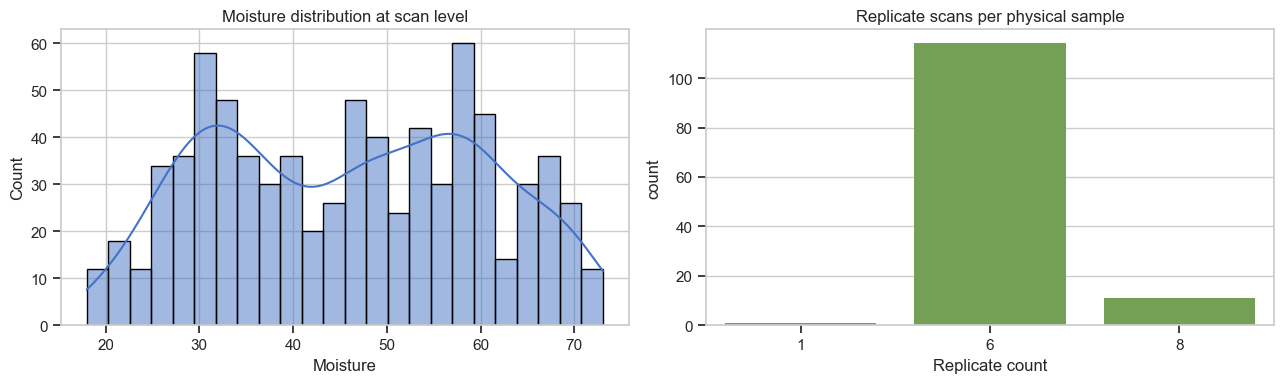

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(raw[cfg.target_col], bins=24, kde=True, ax=axes[0], color="#4472c4")
axes[0].set_title("Moisture distribution at scan level")
axes[0].set_xlabel("Moisture")

sns.countplot(data=replicate_count, x="replicate_count", ax=axes[1], color="#70ad47")
axes[1].set_title("Replicate scans per physical sample")
axes[1].set_xlabel("Replicate count")

plt.tight_layout()
plt.show()


## Next, let's have a quick look at the Spectral matrix

By manual inspection, the spectral matrix appears to be wide. A quick overlay of a subset of scans is enough to see the baseline shape and the overall signal spread.


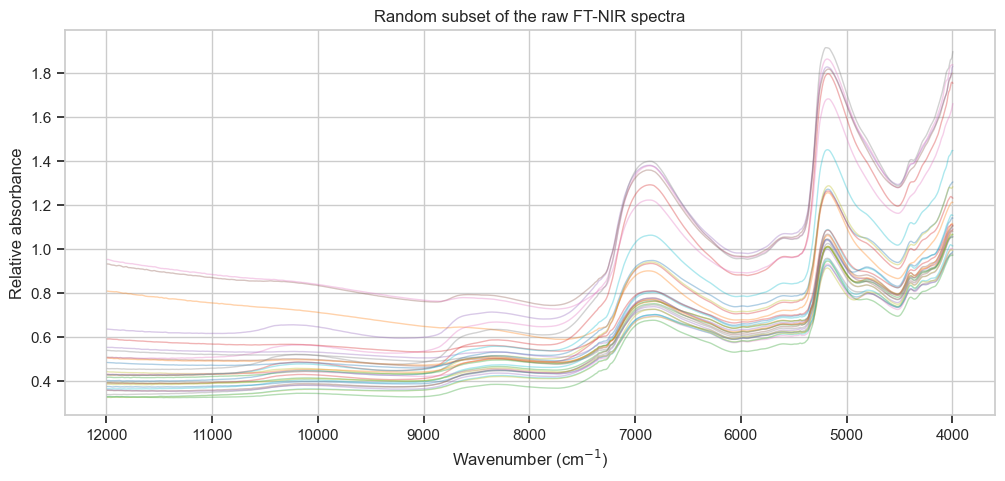

In [29]:
rng = np.random.default_rng(cfg.seed)
sample_rows = rng.choice(raw.index.to_numpy(), size=min(30, len(raw)), replace=False)

plt.figure(figsize=(12, 5))
for idx in sample_rows:
    plt.plot(wavenumbers, raw.loc[idx, spectra_cols].to_numpy(dtype=float), alpha=0.35, linewidth=1)

plt.gca().invert_xaxis()
plt.title("Random subset of the raw FT-NIR spectra")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Relative absorbance")
plt.show()


## Repeatability of replicate scans

Let's quantify repeatability before modelling. The following two summaries will be useful:

1. the average standard deviation of scans within the same physical sample across wavelengths,
2. the moisture target spread within a physical sample.

The second number should be ideally zero (or near zero) because the laboratory moisture value belongs to the physical sample, not to the individual replicate scan.


In [31]:
within_sample_spectral_sd = (
    raw.groupby("physical_sample")[spectra_cols]
       .std()
       .mean(axis=1)
       .rename("mean_within_sample_spectral_sd")
)

within_sample_target_sd = (
    raw.groupby("physical_sample")[cfg.target_col]
       .std()
       .fillna(0.0)
       .rename("within_sample_target_sd")
)

repeatability_table = pd.concat([within_sample_spectral_sd, within_sample_target_sd], axis=1)
repeatability_table.describe().T


,count,mean,std,min,25%,50%,75%,max
mean_within_sample_spectral_sd,125.0,0.02562,0.011723,0.007259,0.01595,0.023003,0.032998,0.067259
within_sample_target_sd,126.0,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


## Averaging replicates
We have two directions that we can undertake:

1. keep all replicate scans and use grouped validation, or
2. average replicates per physical sample to improve signal-to-noise ratio.

I take The second route appears more interesting to me so I will go by that. It gives one feature vector per physical sample. That removes leakage by construction and would (hopefully) help PLSR on small chemometric datasets like the one we are working with.


In [32]:
sample_level = (
    raw.groupby("physical_sample", as_index=False)[spectra_cols + [cfg.target_col]]
       .mean()
)

logger.info(f"Sample level data shape: {sample_level.shape}")


INFO:__main__:Sample level data shape: (126, 1039)


In [35]:
X_all = sample_level[spectra_cols].to_numpy(dtype=float)
y_all = sample_level[cfg.target_col].to_numpy(dtype=float)
sample_ids = sample_level["physical_sample"].to_numpy()

sample_level.head(3)


,physical_sample,11988.51,11980.8,11973.08,11965.37,11957.66,11949.94,11942.23,11934.51,11926.8,11919.08,11911.37,11903.65,11895.94,11888.22,11880.51,11872.79,11865.08,11857.37,11849.65,11841.94,11834.22,11826.51,11818.79,11811.08,11803.36,11795.65,11787.93,11780.22,11772.5,11764.79,11757.08,11749.36,11741.65,11733.93,11726.22,11718.5,11710.79,11703.07,11695.36,11687.64,11679.93,11672.21,11664.5,11656.79,11649.07,11641.36,11633.64,11625.93,11618.21,11610.5,11602.78,11595.07,11587.35,11579.64,11571.92,11564.21,11556.5,11548.78,11541.07,11533.35,11525.64,11517.92,11510.21,11502.49,11494.78,11487.06,11479.35,11471.63,11463.92,11456.21,11448.49,11440.78,11433.06,11425.35,11417.63,11409.92,11402.2,11394.49,11386.77,11379.06,11371.34,11363.63,11355.92,11348.2,11340.49,11332.77,11325.06,11317.34,11309.63,11301.91,11294.2,11286.48,11278.77,11271.05,11263.34,11255.63,11247.91,11240.2,11232.48,...,4752.204,4744.489,4736.774,4729.06,4721.345,4713.63,4705.916,4698.201,4690.487,4682.772,4675.058,4667.343,4659.628,4651.914,4644.199,4636.484,4628.77,4621.055,4613.34,4605.626,4597.911,4590.197,4582.482,4574.768,4567.053,4559.338,4551.624,4543.909,4536.194,4528.479,4520.765,4513.05,4505.336,4497.621,4489.907,4482.192,4474.478,4466.763,4459.048,4451.333,4443.619,4435.904,4428.19,4420.475,4412.76,4405.046,4397.331,4389.617,4381.902,4374.188,4366.473,4358.758,4351.043,4343.329,4335.614,4327.9,4320.185,4312.47,4304.756,4297.041,4289.327,4281.612,4273.897,4266.183,4258.468,4250.753,4243.039,4235.324,4227.61,4219.895,4212.181,4204.466,4196.751,4189.037,4181.322,4173.607,4165.893,4158.178,4150.463,4142.749,4135.034,4127.32,4119.605,4111.891,4104.176,4096.461,4088.747,4081.032,4073.317,4065.603,4057.888,4050.173,4042.459,4034.744,4027.03,4019.315,4011.601,4003.886,3996.171,Moisture
0,3001RanBioMixMalarenergi,0.438562,0.438490,0.438557,0.438652,0.438637,0.438431,0.438067,0.437798,0.437836,0.438032,0.438210,0.438331,0.438266,0.437974,0.437843,0.438002,0.438247,0.438488,0.438496,0.438182,0.437714,0.437522,0.437776,0.438025,0.438069,0.438053,0.437923,0.437537,0.437187,0.437231,0.437550,0.437874,0.438008,0.437873,0.437632,0.437475,0.437293,0.437203,0.437400,0.437520,0.437384,0.437228,0.437186,0.437114,0.436903,0.436752,0.436753,0.436810,0.436900,0.437018,0.437178,0.437409,0.437445,0.437127,0.436858,0.436912,0.437146,0.437345,0.437455,0.437558,0.437739,0.437912,0.437814,0.437542,0.437430,0.437533,0.437623,0.437460,0.437138,0.437007,0.437251,0.437634,0.437881,0.437951,0.437943,0.437993,0.437981,0.437796,0.437666,0.437630,0.437519,0.437508,0.437752,0.438024,0.438134,0.438082,0.437961,0.437925,0.438027,0.438170,0.438244,0.438308,0.438491,0.438746,0.438917,0.438932,0.438860,0.438847,0.438978,...,0.868161,0.866950,0.865393,0.863580,0.861554,0.859389,0.857204,0.855054,0.852871,0.850545,0.848005,0.845215,0.842241,0.839261,0.836365,0.833462,0.830415,0.827259,0.824188,0.821328,0.818656,0.816150,0.813840,0.811742,0.809871,0.808210,0.806657,0.805145,0.803773,0.802744,0.802259,0.802499,0.803662,0.805976,0.809584,0.814465,0.820423,0.827144,0.834380,0.842097,0.850523,0.859807,0.869516,0.878694,0.886318,0.891557,0.893876,0.893283,0.890493,0.886837,0.883841,0.882555,0.883151,0.885205,0.888371,0.892430,0.896971,0.901533,0.905819,0.909586,0.912457,0.914054,0.914358,0.913988,0.913765,0.914006,0.914662,0.915748,0.917385,0.919435,0.92146,0.923045,0.924061,0.924688,0.925134,0.925711,0.926845,0.929103,0.932923,0.938017,0.943898,0.950318,0.957325,0.965050,0.973373,0.982185,0.991582,1.001473,1.011474,1.021491,1.031253,1.040630,1.049623,1.057915,1.065065,1.069776,1.072137,1.073081,1.072896,24.933532
1,3002RanBioMixMalarenergi,0.434417,0.434342,0.434268,0.434148,0.433908,0.433488,0.432979,0.432671,0.432751,0.433018,0.433232,0.433467,0.433560,0.433207,0.432753,0.432595,0.432776,0.433153,0.433268,0.432879,0.432298,0.432035,0.432112,0.432156,0.432144,0.432151,0.432026,0.431593,0.431120,0.431078,0.431330,0.431471,0.431447,0.431332,0.431125,0.430906,0.430747,0.430689,0.430793,0.430899,0.4

## Hold-out split

Since the data file does not include day or facility labels, we cannot create a true site-shift test set. The next best leakage-safe choice is a hold-out made of `unseen physical samples`. We will keep 20% of the physical samples aside and never use them during model selection.


In [36]:
splitter = GroupShuffleSplit(n_splits=1, test_size=cfg.holdout_fraction, random_state=cfg.seed)
dev_idx, holdout_idx = next(splitter.split(X_all, y_all, groups=sample_ids))

X_dev, X_holdout = X_all[dev_idx], X_all[holdout_idx]
y_dev, y_holdout = y_all[dev_idx], y_all[holdout_idx]
id_dev, id_holdout = sample_ids[dev_idx], sample_ids[holdout_idx]

pd.Series(
    {
        "development_samples": len(dev_idx),
        "holdout_samples": len(holdout_idx),
    },
    name="split_summary",
).to_frame()


,split_summary
development_samples,100
holdout_samples,26


## Let's define some helper functions for metrics and chemometric transformers

I define the pre-processing steps as sklearn-compatible transformers so that the modelling code stays compact and leakage-safe. The transformations used are:

- SNV for row-wise centering and scaling,
- MSC for multiplicative scatter correction,
- Savitzky–Golay smoothing or derivatives,
- optional region masking for the moisture-rich 7200–4000 cm<sup>-1</sup> window.


In [37]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def rpd(y_true, y_pred):
    return float(np.std(y_true, ddof=1) / rmse(y_true, y_pred))


def fold_predictions(estimator, X, y, n_splits=5, seed=26):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros_like(y, dtype=float)

    for fit_idx, score_idx in cv.split(X, y):
        fitted = clone(estimator)
        fitted.fit(X[fit_idx], y[fit_idx])
        oof[score_idx] = fitted.predict(X[score_idx]).reshape(-1)

    return oof


def summarise_predictions(y_true, y_pred, prefix=""):
    return {
        f"{prefix}rmse": rmse(y_true, y_pred),
        f"{prefix}r2": float(r2_score(y_true, y_pred)),
        f"{prefix}rpd": rpd(y_true, y_pred),
    }


class SpectralRecipe(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        wavenumbers,
        region="full",
        scatter="snv",
        sg_mode="smooth",
        apply_detrend=False,
        sg_window=15,
        sg_poly=2,
    ):
        self.wavenumbers = np.asarray(wavenumbers, dtype=float)
        self.region = region
        self.scatter = scatter
        self.sg_mode = sg_mode
        self.apply_detrend = apply_detrend
        self.sg_window = sg_window
        self.sg_poly = sg_poly

    def fit(self, X, y=None):
        if self.region == "full":
            self.mask_ = np.ones_like(self.wavenumbers, dtype=bool)
        elif self.region == "moisture_band":
            self.mask_ = (self.wavenumbers <= 7200) & (self.wavenumbers >= 4000)
        else:
            raise ValueError(f"Unknown region: {self.region}")

        X_use = np.asarray(X, dtype=float)[:, self.mask_]

        if self.apply_detrend:
            X_use = detrend(X_use, axis=1, type="linear")

        if self.scatter == "msc":
            self.reference_ = X_use.mean(axis=0)

        self.n_features_in_ = X_use.shape[1]
        return self

    def transform(self, X):
        X_use = np.asarray(X, dtype=float)[:, self.mask_]

        if self.apply_detrend:
            X_use = detrend(X_use, axis=1, type="linear")

        if self.scatter == "snv":
            row_mean = X_use.mean(axis=1, keepdims=True)
            row_std = X_use.std(axis=1, keepdims=True)
            X_use = (X_use - row_mean) / np.where(row_std < 1e-8, 1.0, row_std)

        elif self.scatter == "msc":
            ref = self.reference_
            ref_mean = ref.mean()
            ref_centered = ref - ref_mean
            ref_energy = np.dot(ref_centered, ref_centered)

            corrected = np.empty_like(X_use)
            for row_idx, row in enumerate(X_use):
                row_mean = row.mean()
                slope = np.dot(ref_centered, row - row_mean) / ref_energy if ref_energy > 1e-12 else 1.0
                intercept = row_mean - slope * ref_mean
                corrected[row_idx] = (row - intercept) / (slope if abs(slope) > 1e-8 else 1.0)

            X_use = corrected

        elif self.scatter != "none":
            raise ValueError(f"Unknown scatter mode: {self.scatter}")

        if self.sg_mode != "none":
            derivative_order = {"smooth": 0, "d1": 1, "d2": 2}[self.sg_mode]
            X_use = savgol_filter(
                X_use,
                window_length=self.sg_window,
                polyorder=self.sg_poly,
                deriv=derivative_order,
                axis=1,
            )

        return X_use


## Outlier screen on the development set

We will not remove odd samples by default. We will flag them first, then check whether removal really improves cross-validated PLSR.

The outlier score here combines:

- score distance in PCA space,
- orthogonal residual distance after reconstruction.

Please note that I just used this as a practical chemometric check rather than a claim of absolute anomaly truth.


In [38]:
def flag_pca_outliers(X, recipe, n_components=6, seed=26):
    X_recipe = recipe.fit_transform(X)
    pca = PCA(n_components=n_components, random_state=seed)
    scores = pca.fit_transform(X_recipe)
    rebuilt = pca.inverse_transform(scores)

    score_distance = np.sum((scores / np.sqrt(pca.explained_variance_)) ** 2, axis=1)
    orth_distance = np.sum((X_recipe - rebuilt) ** 2, axis=1)

    score_mad = 1.4826 * np.median(np.abs(score_distance - np.median(score_distance))) + 1e-8
    orth_mad = 1.4826 * np.median(np.abs(orth_distance - np.median(orth_distance))) + 1e-8

    score_z = (score_distance - np.median(score_distance)) / score_mad
    orth_z = (orth_distance - np.median(orth_distance)) / orth_mad

    return (score_z > 3.5) | (orth_z > 3.5), score_distance, orth_distance


seed_recipe = SpectralRecipe(wavenumbers=wavenumbers, region="full", scatter="snv", sg_mode="smooth", apply_detrend=False)
outlier_mask, score_distance, orth_distance = flag_pca_outliers(
    X_dev,
    seed_recipe,
    n_components=cfg.pca_outlier_components,
    seed=cfg.seed,
)

flagged_samples = pd.DataFrame(
    {
        "physical_sample": id_dev[outlier_mask],
        "moisture": y_dev[outlier_mask],
        "score_distance": score_distance[outlier_mask],
        "orth_distance": orth_distance[outlier_mask],
    }
).sort_values(["score_distance", "orth_distance"], ascending=False)

flagged_samples


,physical_sample,moisture,score_distance,orth_distance
11,3086RanBioMixMalarenergi,20.621206,33.729280,0.155252
8,3079RanBioMixMalarenergi,47.701578,20.581734,0.052235
9,3080RanBioMixMalarenergi,41.378005,19.236975,0.032720
2,3048RanBioMixMalarenergi,46.633770,16.032889,0.052585
3,3056RanBioMixMalarenergi_fault,59.641349,15.105527,0.213171
13,3101RanBioMixMalarenergi,36.877915,14.805243,0.119495
4,3068RanBioMixMalarenergi,56.115081,14.623588,0.017819
5,3074RanBioMixMalarenergi,39.413388,14.238272,0.024017
7,3078RanBioMixMalarenergi,55.857197,13.607520,0.183754
6,3077RanBioMixMalarenergi,61.569492,13.187376,0.026168


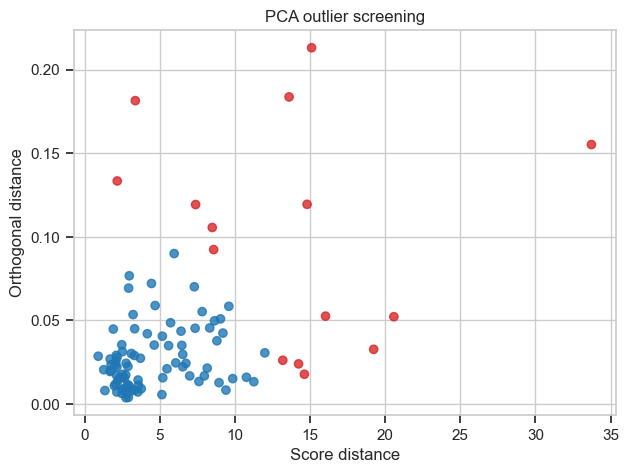

In [40]:
plt.figure(figsize=(7, 5))
plt.scatter(score_distance, orth_distance, c=np.where(outlier_mask, "tab:red", "tab:blue"), alpha=0.8)
plt.xlabel("Score distance")
plt.ylabel("Orthogonal distance")
plt.title("PCA outlier screening")
plt.show()


## Pre-processing recipe scan with PLSR

Since we are using PLSR as the preferred baseline, let's use it first to rank the spectral pre-processing options.

The grid below compares:

- scatter correction: SNV vs MSC,
- SG mode: smoothing vs first derivative vs second derivative,
- region: full spectrum vs moisture-rich band,
- latent components: 2 to 16.


In [41]:
def make_plsr_pipeline(recipe, n_components):
    return Pipeline(
        [
            ("recipe", SpectralRecipe(wavenumbers=wavenumbers, **recipe)),
            ("model", PLSRegression(n_components=n_components, scale=False)),
        ]
    )


recipe_grid = [
    {"scatter": scatter, "sg_mode": sg_mode, "region": region, "apply_detrend": False}
    for scatter, sg_mode, region in product(
        ["snv", "msc"],
        ["smooth", "d1", "d2"],
        ["full", "moisture_band"],
    )
]

pls_scan_rows = []

for recipe in recipe_grid:
    best_row = None

    for n_components in range(2, 17):
        candidate = make_plsr_pipeline(recipe, n_components=n_components)
        dev_oof = fold_predictions(candidate, X_dev, y_dev, n_splits=cfg.folds, seed=cfg.seed)

        row = {
            "model": "PLSR",
            "n_components": n_components,
            **recipe,
            **summarise_predictions(y_dev, dev_oof, prefix="cv_"),
        }

        if (best_row is None) or (row["cv_rmse"] < best_row["cv_rmse"]):
            best_row = row

    pls_scan_rows.append(best_row)

pls_scan = pd.DataFrame(pls_scan_rows).sort_values("cv_rmse").reset_index(drop=True)
pls_scan


,model,n_components,scatter,sg_mode,region,apply_detrend,cv_rmse,cv_r2,cv_rpd
0,PLSR,5,snv,d2,moisture_band,False,2.056547,0.979177,6.964798
1,PLSR,10,msc,smooth,moisture_band,False,2.071613,0.978871,6.914147
2,PLSR,11,msc,smooth,full,False,2.082583,0.978646,6.877726
3,PLSR,12,snv,smooth,moisture_band,False,2.092208,0.978448,6.846084
4,PLSR,12,snv,smooth,full,False,2.098111,0.978327,6.826826
5,PLSR,5,msc,d2,moisture_band,False,2.104611,0.978192,6.805741
6,PLSR,10,snv,d1,moisture_band,False,2.124205,0.977784,6.742964
7,PLSR,10,msc,d1,moisture_band,False,2.187287,0.976445,6.548493
8,PLSR,11,msc,d1,full,False,2.226224,0.975599,6.433960
9,PLSR,12,snv,d1,full,False,2.240841,0.975277,6.391990


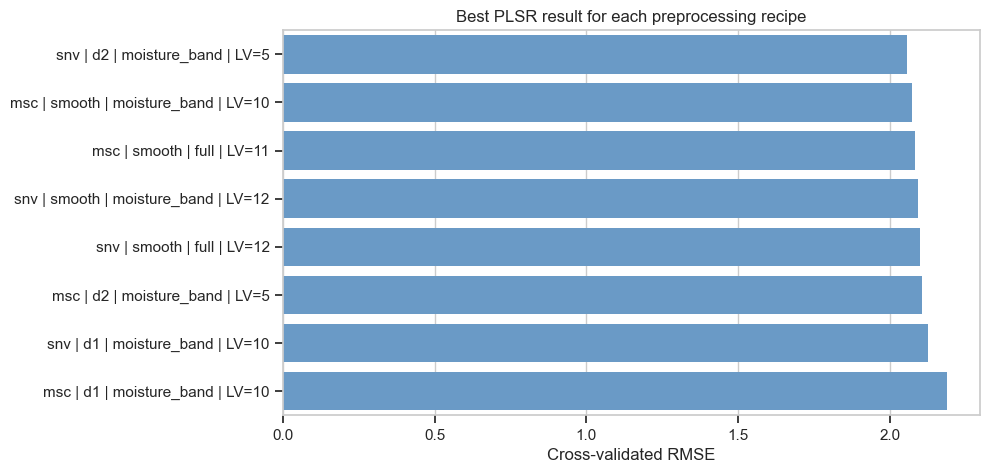

In [42]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=pls_scan.head(8),
    x="cv_rmse",
    y=pls_scan.head(8).apply(
        lambda row: f'{row["scatter"]} | {row["sg_mode"]} | {row["region"]} | LV={int(row["n_components"])}',
        axis=1,
    ),
    color="#5b9bd5",
)
plt.title("Best PLSR result for each preprocessing recipe")
plt.xlabel("Cross-validated RMSE")
plt.ylabel("")
plt.show()


## Outlier decision

Let's compare the best PLSR recipe with and without the flagged outliers. If removing flagged samples does not help, we will keep the full development set (well, this is a conservative choice :))


In [43]:
best_recipe = pls_scan.iloc[0][["scatter", "sg_mode", "region", "apply_detrend"]].to_dict()
best_lv = int(pls_scan.iloc[0]["n_components"])

full_pls = make_plsr_pipeline(best_recipe, n_components=best_lv)
full_pred = fold_predictions(full_pls, X_dev, y_dev, n_splits=cfg.folds, seed=cfg.seed)

keep_mask = ~outlier_mask
trimmed_pred = fold_predictions(full_pls, X_dev[keep_mask], y_dev[keep_mask], n_splits=cfg.folds, seed=cfg.seed)

outlier_decision = pd.DataFrame(
    [
        {"set": "development set kept intact", **summarise_predictions(y_dev, full_pred)},
        {"set": "flagged outliers removed", **summarise_predictions(y_dev[keep_mask], trimmed_pred)},
    ]
)

outlier_decision


,set,rmse,r2,rpd
0,development set kept intact,2.056547,0.979177,6.964798
1,flagged outliers removed,2.115751,0.978993,6.940435


## Model family comparison

Now that the leading spectral recipe is known, let's compare three model families:

- PLSR as the chemometric baseline,
- SVR with an RBF kernel,
- ANN using a compact MLP regressor.

For SVR and ANN we will add standardisation and PCA after the chemometric recipe. Doing so will reduce dimensionality and (well, hopefully) stabilise the non-linear models.


In [44]:
top_recipes = pls_scan.head(2)[["scatter", "sg_mode", "region", "apply_detrend"]].to_dict(orient="records")


def build_plsr(recipe, latent_variables):
    return Pipeline(
        [
            ("recipe", SpectralRecipe(wavenumbers=wavenumbers, **recipe)),
            ("model", PLSRegression(n_components=latent_variables, scale=False)),
        ]
    )


def build_svr(recipe, pca_components, c_value, gamma_value, epsilon_value=0.1):
    return Pipeline(
        [
            ("recipe", SpectralRecipe(wavenumbers=wavenumbers, **recipe)),
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=pca_components, random_state=cfg.seed)),
            ("model", SVR(kernel="rbf", C=c_value, gamma=gamma_value, epsilon=epsilon_value)),
        ]
    )


def build_ann(recipe, pca_components, hidden_layers, alpha_value):
    return Pipeline(
        [
            ("recipe", SpectralRecipe(wavenumbers=wavenumbers, **recipe)),
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=pca_components, random_state=cfg.seed)),
            (
                "model",
                MLPRegressor(
                    hidden_layer_sizes=hidden_layers,
                    alpha=alpha_value,
                    learning_rate_init=1e-3,
                    max_iter=3000,
                    early_stopping=True,
                    validation_fraction=0.15,
                    random_state=cfg.seed,
                ),
            ),
        ]
    )


comparison_rows = []

for recipe in top_recipes:
    for latent_variables in range(4, 17):
        candidate = build_plsr(recipe, latent_variables=latent_variables)
        cv_pred = fold_predictions(candidate, X_dev, y_dev, n_splits=cfg.folds, seed=cfg.seed)

        comparison_rows.append(
            {
                "family": "PLSR",
                "recipe_label": f'{recipe["scatter"]} | {recipe["sg_mode"]} | {recipe["region"]}',
                "settings": f"LV={latent_variables}",
                "estimator": candidate,
                **summarise_predictions(y_dev, cv_pred, prefix="cv_"),
            }
        )

for recipe in top_recipes:
    for pca_components, c_value, gamma_value in product([18, 24, 30], [5, 20, 50], ["scale", 0.03]):
        candidate = build_svr(recipe, pca_components=pca_components, c_value=c_value, gamma_value=gamma_value)
        cv_pred = fold_predictions(candidate, X_dev, y_dev, n_splits=cfg.folds, seed=cfg.seed)

        comparison_rows.append(
            {
                "family": "SVR",
                "recipe_label": f'{recipe["scatter"]} | {recipe["sg_mode"]} | {recipe["region"]}',
                "settings": f"PCA={pca_components}, C={c_value}, gamma={gamma_value}",
                "estimator": candidate,
                **summarise_predictions(y_dev, cv_pred, prefix="cv_"),
            }
        )

for recipe in top_recipes:
    for pca_components, hidden_layers, alpha_value in product(
        [18, 24, 30],
        [(48,), (64, 24), (96, 48)],
        [1e-4, 1e-3],
    ):
        candidate = build_ann(recipe, pca_components=pca_components, hidden_layers=hidden_layers, alpha_value=alpha_value)
        cv_pred = fold_predictions(candidate, X_dev, y_dev, n_splits=cfg.folds, seed=cfg.seed)

        comparison_rows.append(
            {
                "family": "ANN",
                "recipe_label": f'{recipe["scatter"]} | {recipe["sg_mode"]} | {recipe["region"]}',
                "settings": f"PCA={pca_components}, hidden={hidden_layers}, alpha={alpha_value}",
                "estimator": candidate,
                **summarise_predictions(y_dev, cv_pred, prefix="cv_"),
            }
        )

comparison = pd.DataFrame(comparison_rows).sort_values("cv_rmse").reset_index(drop=True)
comparison.head(15)


,family,recipe_label,settings,estimator,cv_rmse,cv_r2,cv_rpd
0,PLSR,snv | d2 | moisture_band,LV=5,"(SpectralRecipe(region='moisture_band', sg_mod...",2.056547,0.979177,6.964798
1,PLSR,msc | smooth | moisture_band,LV=10,"(SpectralRecipe(region='moisture_band', scatte...",2.071613,0.978871,6.914147
2,PLSR,snv | d2 | moisture_band,LV=7,"(SpectralRecipe(region='moisture_band', sg_mod...",2.088555,0.978524,6.858061
3,PLSR,snv | d2 | moisture_band,LV=8,"(SpectralRecipe(region='moisture_band', sg_mod...",2.091522,0.978463,6.848332
4,PLSR,snv | d2 | moisture_band,LV=6,"(SpectralRecipe(region='moisture_band', sg_mod...",2.102408,0.978238,6.812871
5,PLSR,msc | smooth | moisture_band,LV=11,"(SpectralRecipe(region='moisture_band', scatte...",2.120477,0.977862,6.754817
6,PLSR,msc | smooth | moisture_band,LV=13,"(SpectralRecipe(region='moisture_band', scatte...",2.125593,0.977755,6.738561
7,PLSR,msc | smooth | moisture_band,LV=15,"(SpectralRecipe(region='moisture_band', scatte...",2.136342,0.977530,6.704653
8,PLSR,msc | smooth | moisture_band,LV=14,"(SpectralRecipe(region='moisture_band', scatte...",2.141215,0.977427,6.689397
9,PLSR,msc | smooth | moisture_band,LV=12,"(SpectralRecipe(region='moisture_band', scatte...",2.148010,0.977283,6.668233


In [45]:
best_by_family = (
    comparison.sort_values("cv_rmse")
              .groupby("family", as_index=False)
              .first()
              .sort_values("cv_rmse")
)

best_by_family[["family", "recipe_label", "settings", "cv_rmse", "cv_r2", "cv_rpd"]]


,family,recipe_label,settings,cv_rmse,cv_r2,cv_rpd
1,PLSR,snv | d2 | moisture_band,LV=5,2.056547,0.979177,6.964798
2,SVR,snv | d2 | moisture_band,"PCA=18, C=20, gamma=scale",2.419584,0.971176,5.919792
0,ANN,msc | smooth | moisture_band,"PCA=24, hidden=(64, 24), alpha=0.001",6.391302,0.798883,2.241083


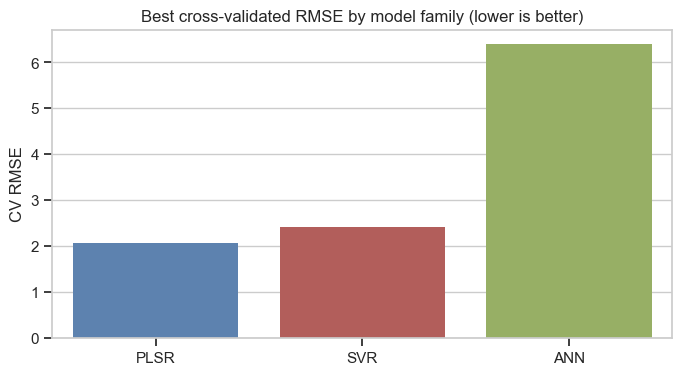

In [47]:
plt.figure(figsize=(8, 4))
sns.barplot(data=best_by_family, x="family", y="cv_rmse", palette=["#4f81bd", "#c0504d", "#9bbb59"])
plt.title("Best cross-validated RMSE by model family (lower is better)")
plt.xlabel("")
plt.ylabel("CV RMSE")
plt.show()


## Hold-out evaluation

Let's refit the best configuration from each family on the full development set and evaluate it on the untouched hold-out samples.


In [48]:
holdout_rows = []

for _, row in best_by_family.iterrows():
    fitted = clone(row["estimator"])
    fitted.fit(X_dev, y_dev)
    holdout_pred = fitted.predict(X_holdout).reshape(-1)

    holdout_rows.append(
        {
            "family": row["family"],
            "recipe_label": row["recipe_label"],
            "settings": row["settings"],
            **summarise_predictions(y_holdout, holdout_pred, prefix="holdout_"),
        }
    )

holdout_results = pd.DataFrame(holdout_rows).sort_values("holdout_rmse").reset_index(drop=True)
holdout_results


,family,recipe_label,settings,holdout_rmse,holdout_r2,holdout_rpd
0,SVR,snv | d2 | moisture_band,"PCA=18, C=20, gamma=scale",2.931809,0.954283,4.769538
1,PLSR,snv | d2 | moisture_band,LV=5,3.197385,0.945625,4.373378
2,ANN,msc | smooth | moisture_band,"PCA=24, hidden=(64, 24), alpha=0.001",6.712882,0.760322,2.083065


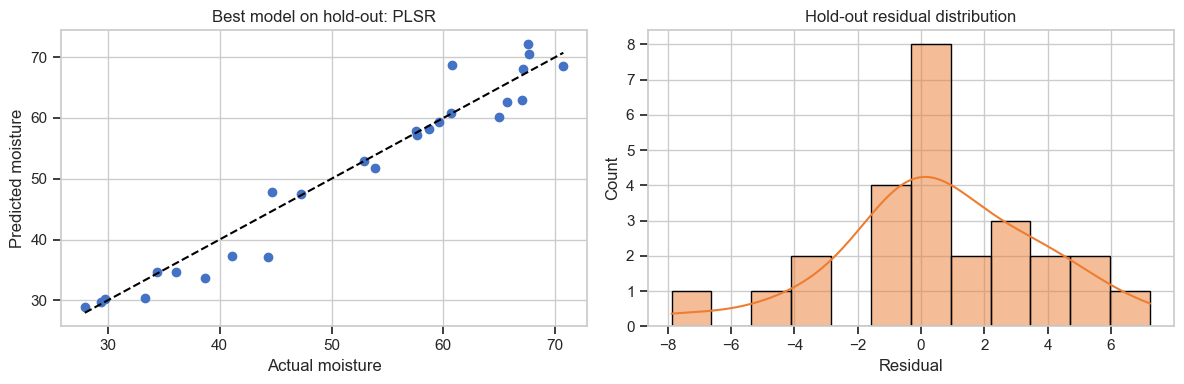

,physical_sample,actual,predicted,residual
5,3033RanBioMixMalarenergi,27.938992,28.813968,-0.874975
8,3052RanBioMixMalarenergi,29.370391,29.686973,-0.316582
4,3032RanBioMixMalarenergi,29.767688,30.146761,-0.379073
2,3016RanBioMixMalarenergi,33.325399,30.381061,2.944338
7,3044RanBioMixMalarenergi,34.386064,34.690080,-0.304016
25,3125RanBioMixMalarenergi,36.075322,34.727500,1.347823
21,3117RanBioMixMalarenergi,38.684588,33.724546,4.960042
20,3100RanBioMixMalarenergi,41.101152,37.257994,3.843158
6,3041RanBioMixMalarenergi,44.360082,37.125370,7.234712
0,3013RanBioMixMalarenergi,44.710818,47.876185,-3.165367


In [49]:
winner = best_by_family.sort_values("cv_rmse").iloc[0]
winner_model = clone(winner["estimator"]).fit(X_dev, y_dev)
winner_pred = winner_model.predict(X_holdout).reshape(-1)

residual_frame = pd.DataFrame(
    {
        "physical_sample": id_holdout,
        "actual": y_holdout,
        "predicted": winner_pred,
        "residual": y_holdout - winner_pred,
    }
).sort_values("actual")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_holdout, winner_pred, color="#4472c4")
axes[0].plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], linestyle="--", color="black")
axes[0].set_title(f'Best model on hold-out: {winner["family"]}')
axes[0].set_xlabel("Actual moisture")
axes[0].set_ylabel("Predicted moisture")

sns.histplot(residual_frame["residual"], bins=12, kde=True, ax=axes[1], color="#ed7d31")
axes[1].set_title("Hold-out residual distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

residual_frame.head(10)
